
# Enterprise BI — Data Cleaning and Quality Audit

## TL;DR

This notebook audits all raw and cleaned datasets for missing values,
duplicate rows, missing primary keys and row-count changes.

## Context & Methods

- Raw files are read from `Raw_Data`.
- Cleaned files are read from `Cleaned_Data`.
- Individual records are not manually edited.
- Cleaning and validation are reproducible.


In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

CURRENT_FOLDER = Path.cwd()

if CURRENT_FOLDER.name.lower() == "python":
    PROJECT_FOLDER = CURRENT_FOLDER.parent
else:
    PROJECT_FOLDER = CURRENT_FOLDER

RAW_FOLDER = PROJECT_FOLDER / "Raw_Data"
CLEANED_FOLDER = PROJECT_FOLDER / "Cleaned_Data"
QUALITY_FOLDER = PROJECT_FOLDER / "Data_Quality"

QUALITY_FOLDER.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_FOLDER)
print("Raw folder exists:", RAW_FOLDER.exists())
print("Cleaned folder exists:", CLEANED_FOLDER.exists())


Project folder: c:\Users\Hooooo\Documents\Excel\Enterprise_BI_Root_Cause_Profitability_Dataset\Final_Data_Analyst_Project
Raw folder exists: True
Cleaned folder exists: True


## Data Audit

In [2]:

def audit_csv_folder(folder, source_name):
    audit_rows = []

    if not folder.exists():
        return pd.DataFrame()

    for file_path in sorted(folder.glob("*.csv")):
        dataframe = pd.read_csv(
            file_path,
            low_memory=False
        )

        primary_key_column = (
            dataframe.columns[0]
            if len(dataframe.columns) > 0
            else None
        )

        missing_primary_keys = (
            dataframe[primary_key_column].isna().sum()
            if primary_key_column
            else 0
        )

        duplicate_rows = dataframe.duplicated().sum()
        missing_cells = dataframe.isna().sum().sum()
        total_cells = dataframe.shape[0] * dataframe.shape[1]

        completeness_percentage = (
            (1 - missing_cells / total_cells) * 100
            if total_cells > 0
            else 0
        )

        valid_records = max(
            len(dataframe)
            - duplicate_rows
            - missing_primary_keys,
            0
        )

        quality_percentage = (
            valid_records / len(dataframe) * 100
            if len(dataframe) > 0
            else 0
        )

        audit_rows.append(
            {
                "Source": source_name,
                "Dataset": file_path.stem,
                "Total_Records": len(dataframe),
                "Total_Columns": len(dataframe.columns),
                "Duplicate_Rows": int(duplicate_rows),
                "Missing_Cells": int(missing_cells),
                "Missing_Primary_Keys": int(missing_primary_keys),
                "Valid_Records": int(valid_records),
                "Completeness_Percentage": round(
                    completeness_percentage,
                    2
                ),
                "Quality_Percentage": round(
                    quality_percentage,
                    2
                )
            }
        )

    return pd.DataFrame(audit_rows)


raw_audit = audit_csv_folder(
    RAW_FOLDER,
    "Raw"
)

cleaned_audit = audit_csv_folder(
    CLEANED_FOLDER,
    "Cleaned"
)

quality_audit = pd.concat(
    [
        raw_audit,
        cleaned_audit
    ],
    ignore_index=True
)

quality_audit


,Source,Dataset,Total_Records,Total_Columns,Duplicate_Rows,Missing_Cells,Missing_Primary_Keys,Valid_Records,Completeness_Percentage,Quality_Percentage
0,Raw,customer_complaints,10000,9,0,2500,0,10000,97.22,100.0
1,Raw,customer_master,20020,11,0,71,20,20000,99.97,99.9
2,Raw,employee_attendance,50000,8,0,0,0,50000,100.00,100.0
3,Raw,employee_master,500,8,0,11,1,499,99.72,99.8
4,Raw,inventory,120000,13,0,0,0,120000,100.00,100.0
5,Raw,invoices,102000,8,0,0,0,102000,100.00,100.0
6,Raw,marketing_campaigns,5000,11,0,0,0,5000,100.00,100.0
7,Raw,monthly_targets,240,10,0,0,0,240,100.00,100.0
8,Raw,order_items,250000,8,0,0,0,250000,100.00,100.0
9,Raw,orders,100000,8,0,0,0,100000,100.00,100.0


## Raw vs Cleaned Comparison

In [3]:

if not raw_audit.empty and not cleaned_audit.empty:
    comparison = raw_audit.merge(
        cleaned_audit,
        on="Dataset",
        how="outer",
        suffixes=("_Raw", "_Cleaned")
    )

    comparison["Rows_Removed"] = (
        comparison["Total_Records_Raw"]
        - comparison["Total_Records_Cleaned"]
    )

    comparison["Duplicate_Reduction"] = (
        comparison["Duplicate_Rows_Raw"]
        - comparison["Duplicate_Rows_Cleaned"]
    )

    comparison["Missing_Cell_Reduction"] = (
        comparison["Missing_Cells_Raw"]
        - comparison["Missing_Cells_Cleaned"]
    )

    comparison.to_csv(
        QUALITY_FOLDER
        / "Notebook_Raw_Cleaned_Comparison.csv",
        index=False
    )

    display(comparison)
else:
    comparison = pd.DataFrame()
    print("Raw or Cleaned files unavailable.")


,Source_Raw,Dataset,Total_Records_Raw,Total_Columns_Raw,Duplicate_Rows_Raw,Missing_Cells_Raw,Missing_Primary_Keys_Raw,Valid_Records_Raw,Completeness_Percentage_Raw,Quality_Percentage_Raw,Source_Cleaned,Total_Records_Cleaned,Total_Columns_Cleaned,Duplicate_Rows_Cleaned,Missing_Cells_Cleaned,Missing_Primary_Keys_Cleaned,Valid_Records_Cleaned,Completeness_Percentage_Cleaned,Quality_Percentage_Cleaned,Rows_Removed,Duplicate_Reduction,Missing_Cell_Reduction
0,Raw,customer_complaints,10000,9,0,2500,0,10000,97.22,100.0,Cleaned,9920,9,0,2482,0,9920,97.22,100.0,80,0,18
1,Raw,customer_master,20020,11,0,71,20,20000,99.97,99.9,Cleaned,19955,11,0,51,0,19955,99.98,100.0,65,0,20
2,Raw,employee_attendance,50000,8,0,0,0,50000,100.00,100.0,Cleaned,49390,8,0,0,0,49390,100.00,100.0,610,0,0
3,Raw,employee_master,500,8,0,11,1,499,99.72,99.8,Cleaned,499,8,0,10,0,499,99.75,100.0,1,0,1
4,Raw,inventory,120000,13,0,0,0,120000,100.00,100.0,Cleaned,119040,13,0,0,0,119040,100.00,100.0,960,0,0
5,Raw,invoices,102000,8,0,0,0,102000,100.00,100.0,Cleaned,101416,8,0,0,0,101416,100.00,100.0,584,0,0
6,Raw,marketing_campaigns,5000,11,0,0,0,5000,100.00,100.0,Cleaned,5000,11,0,0,0,5000,100.00,100.0,0,0,0
7,Raw,monthly_targets,240,10,0,0,0,240,100.00,100.0,Cleaned,240,10,0,0,0,240,100.00,100.0,0,0,0
8,Raw,order_items,250000,8,0,0,0,250000,100.00,100.0,Cleaned,246370,8,0,0,0,246370,100.00,100.0,3630,0,0
9,Raw,orders,100000,8,0,0,0,100000,100.00,100.0,Cleaned,99435,8,0,0,0,99435,100.00,100.0,565,0,0


## Data Quality Visual

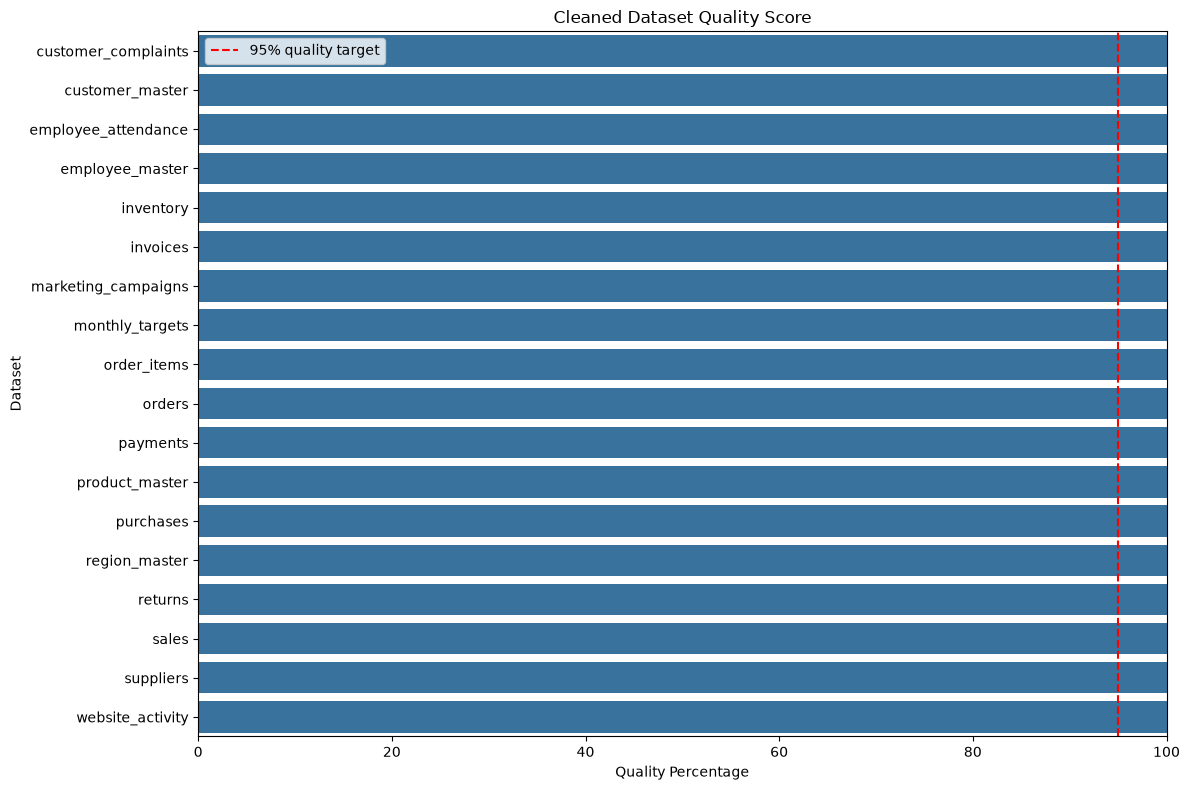

In [4]:

if not quality_audit.empty:
    chart_data = quality_audit[
        quality_audit["Source"] == "Cleaned"
    ].sort_values(
        "Quality_Percentage"
    )

    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=chart_data,
        y="Dataset",
        x="Quality_Percentage",
        color="#2774AE"
    )

    plt.axvline(
        95,
        color="red",
        linestyle="--",
        label="95% quality target"
    )

    plt.title("Cleaned Dataset Quality Score")
    plt.xlabel("Quality Percentage")
    plt.ylabel("Dataset")
    plt.xlim(0, 100)
    plt.legend()
    plt.tight_layout()
    plt.show()



## Takeaways

- Cleaning is performed through repeatable code rather than manual row edits.
- Duplicate and missing-key checks are retained as an audit trail.
- Foreign-key and reconciliation issues must be reviewed separately because a
  structurally valid record may still be commercially incorrect.
